In [97]:
# Data import
from sklearn.datasets import fetch_openml

# Data handling
import numpy as np
import pandas as pd
import sklearn

# Feature pre-processing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Model and training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
print(sklearn.__version__)


1.8.0


In [29]:
dataset = fetch_openml(data_id=4538, as_frame=False)

In [30]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['phase'] = dataset.target
corr_matrix = df.iloc[:, :-1].astype(float).corr()

<Axes: >

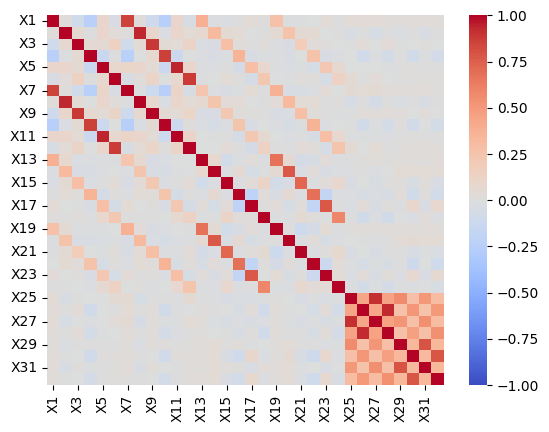

In [31]:
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

In [32]:
df.nunique()

X1       9822
X2       9826
X3       9625
X4       9810
X5       9840
X6       9703
X7       9816
X8       9810
X9       9595
X10      9817
X11      9827
X12      9664
X13      9466
X14      9489
X15      8395
X16      9557
X17      9584
X18      8724
X19      9425
X20      9380
X21      8304
X22      9473
X23      9533
X24      8714
X25      9831
X26      9844
X27      9824
X28      9827
X29      9509
X30      9635
X31      9493
X32      9576
phase       5
dtype: int64

Text(0.5, 1.0, 'Duplicate labeled features')

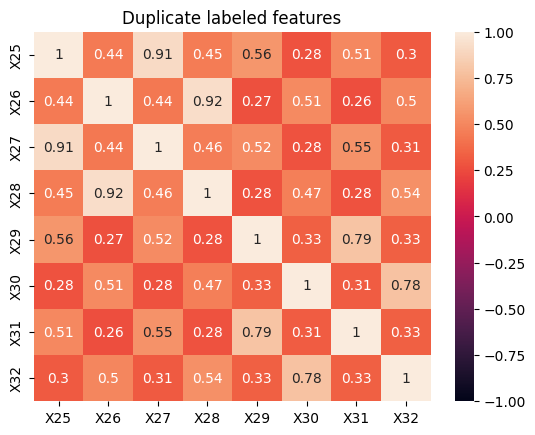

In [33]:
duplicate_set = df.iloc[:, 24:32].astype(float)
corr_duplicates = duplicate_set.corr();
sns.heatmap(corr_duplicates, annot=True, vmin =-1, vmax=1)
plt.title("Duplicate labeled features")

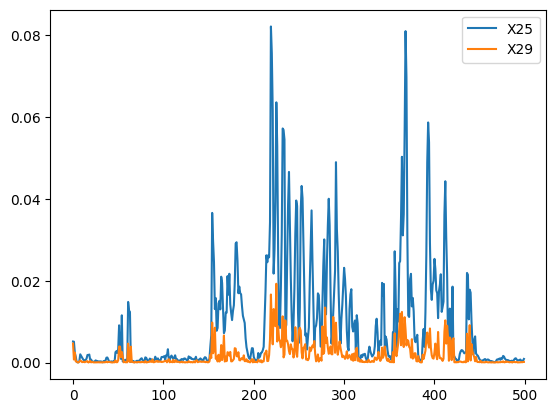

In [34]:
plt.plot(df['X25'].iloc[:500], label ='X25')
plt.plot(df['X29'].iloc[:500], label ='X29')
plt.legend()

Text(0.5, 1.0, 'Logically correlated features (velocity) ')

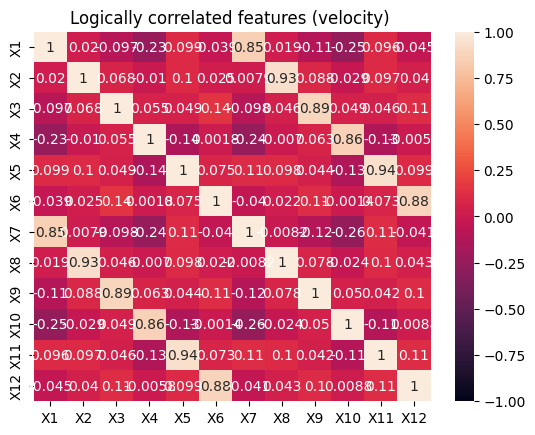

In [35]:
velocity_set = df.iloc[:, 0:12].astype(float)
corr_velocity = velocity_set.corr();
sns.heatmap(corr_velocity, annot=True, vmin =-1, vmax=1)
plt.title("Logically correlated features (velocity) ")

Text(0.5, 1.0, 'Logically correlated features (acceleration) ')

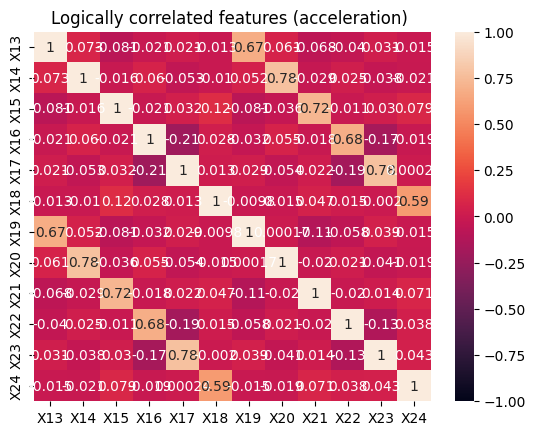

In [36]:
acceleration_set = df.iloc[:, 12:24].astype(float)
corr_acceleration = acceleration_set.corr();
sns.heatmap(corr_acceleration, annot=True, vmin =-1, vmax=1)
plt.title("Logically correlated features (acceleration) ")

In [37]:
X = dataset.data.astype(float)
y = dataset.target

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape
X_test.shape

(1975, 32)

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [51]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [52]:
pca.components_.shape

(20, 32)

In [53]:
pca.explained_variance_ratio_

array([0.13387106, 0.09433436, 0.08271246, 0.07783697, 0.06857916,
       0.062856  , 0.05991018, 0.05094314, 0.04688328, 0.04519274,
       0.03886964, 0.03734302, 0.03273305, 0.0306769 , 0.02652734,
       0.01855865, 0.01428824, 0.01232341, 0.01086546, 0.00904567])

<function matplotlib.pyplot.show(close=None, block=None)>

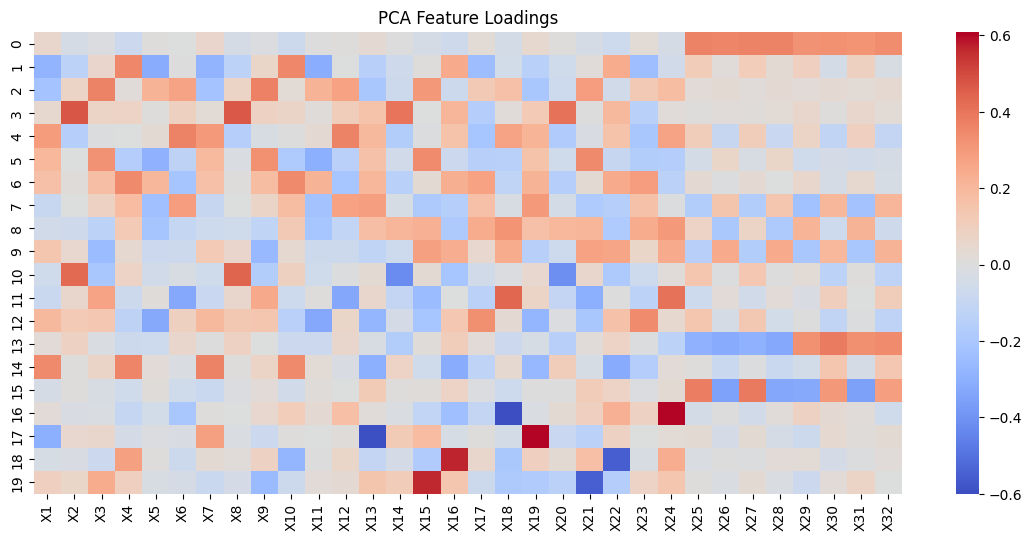

In [54]:
loadings = pd.DataFrame(
    pca.components_,
    columns=dataset.feature_names
)
plt.figure(figsize=(14, 6))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("PCA Feature Loadings")
plt.show

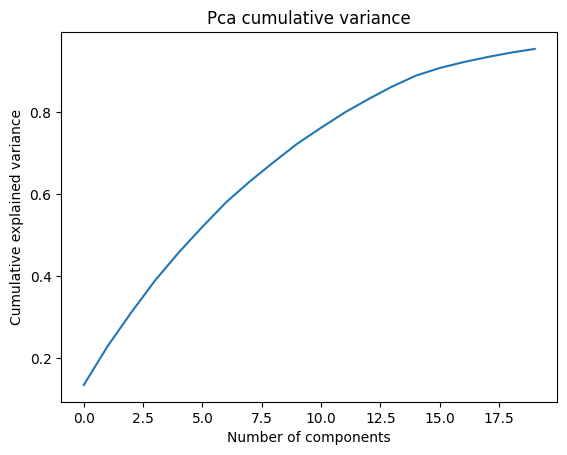

In [55]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Pca cumulative variance")
plt.show()

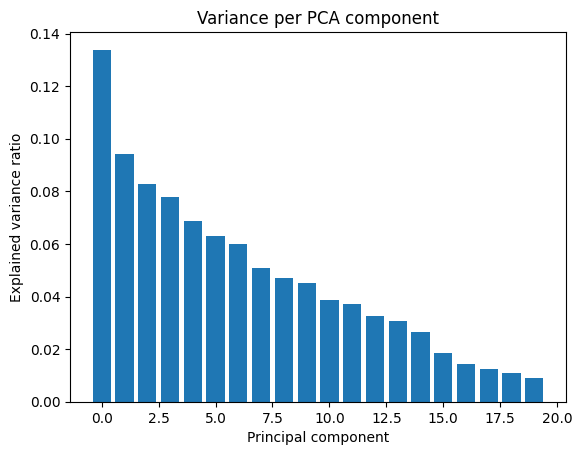

In [56]:
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Variance per PCA component")
plt.show()

In [83]:
#X_train, X_test, y_train, y_test = train_test_split(
#    X_train_pca, y, test_size=0.2, random_state=42, stratify=y)

logreg_pca = LogisticRegression(
    max_iter=10000, solver='lbfgs')

logreg_pca.fit(X_train_pca, y_train)

y_pred_pca = clf.predict(X_test_pca)

In [94]:
acc = accuracy_score(y_test, y_pred_pca)
print(acc)

0.4622784810126582


<function matplotlib.pyplot.show(close=None, block=None)>

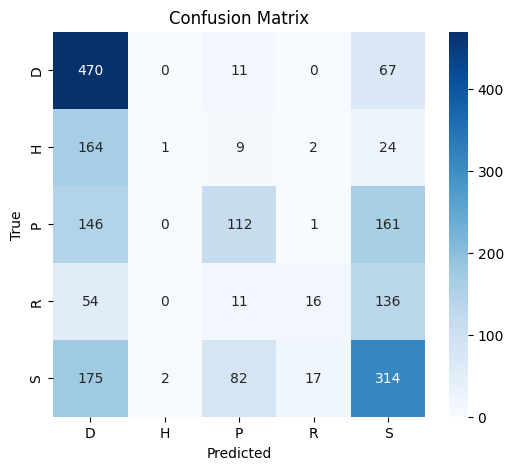

In [86]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show

In [87]:
print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           D       0.47      0.86      0.60       548
           H       0.33      0.01      0.01       200
           P       0.50      0.27      0.35       420
           R       0.44      0.07      0.13       217
           S       0.45      0.53      0.49       590

    accuracy                           0.46      1975
   macro avg       0.44      0.35      0.31      1975
weighted avg       0.45      0.46      0.40      1975



In [102]:
logreg_no_pca = LogisticRegression(max_iter=10000, solver='lbfgs', class_weight='balanced')
logreg_no_pca.fit(X_train, y_train)

y_pred_no_pca = logreg_no_pca.predict(X_test)

In [103]:
print(accuracy_score(y_test, y_pred_no_pca))
print(classification_report(y_test, y_pred_no_pca))

0.4253164556962025
              precision    recall  f1-score   support

           D       0.46      0.86      0.60       548
           H       0.10      0.04      0.05       200
           P       0.42      0.36      0.39       420
           R       0.34      0.57      0.43       217
           S       0.56      0.15      0.23       590

    accuracy                           0.43      1975
   macro avg       0.38      0.39      0.34      1975
weighted avg       0.43      0.43      0.37      1975

